<a href="https://colab.research.google.com/github/TP2836/crypto-sentiment-analysis/blob/main/crypto_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cryptocurrency Market Trends and News Sentiment Analysis

**Name: Tianzheng Peng**

**Date: 05/04/2026**

## Project Objective
This project investigates the relationship between cryptocurrency market performance and news media sentiment. Using real-time market data from the CoinGecko API and news articles from The Guardian API, I analyze whether media coverage tone correlates with price movements. FinBERT via Hugging Face is used to classify each article headline as positive, neutral, or negative.

## Data Overview
- **CoinGecko API**: Real-time market data for the top 20 cryptocurrencies by market cap. No API key required. Retrieved May 2026.
- **The Guardian API**: Recent English-language news articles across 10 major coins. ~100 articles total.
- **Hugging Face FinBERT**: Financial sentiment model used to score each article headline.

## D1. Library Imports

In [1]:
import requests
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime

print("All libraries imported successfully.")

All libraries imported successfully.


## D2. Data Retrieval and Pre-Processing

### 2.1 CoinGecko API

In [2]:
url_cg = "https://api.coingecko.com/api/v3/coins/markets"
params_cg = {
    "vs_currency"            : "usd",
    "order"                   : "market_cap_desc",
    "per_page"                : 20,
    "page"                    : 1,
    "price_change_percentage" : "7d",
    "sparkline"               : "false"
}

resp_cg = requests.get(url_cg, params=params_cg)
print("HTTP status code:", resp_cg.status_code)

data_cg = resp_cg.json()
print("Records returned:", len(data_cg))

HTTP status code: 200
Records returned: 20


In [3]:
crypto = pd.DataFrame(data_cg)

crypto = crypto.rename(columns={
    "market_cap_rank"                        : "rank",
    "current_price"                           : "price_usd",
    "price_change_percentage_24h"             : "change_24h_pct",
    "price_change_percentage_7d_in_currency"  : "change_7d_pct",
    "market_cap"                              : "market_cap_usd",
    "total_volume"                            : "volume_24h_usd",
})

crypto["symbol"] = crypto["symbol"].str.upper()

def assign_tier(market_cap):
    if market_cap >= 10_000_000_000:
        return "Large Cap (>$10B)"
    elif market_cap >= 1_000_000_000:
        return "Mid Cap ($1B-$10B)"
    else:
        return "Small Cap (<$1B)"

crypto["tier"] = crypto["market_cap_usd"].apply(assign_tier)

print("Shape:", crypto.shape)
crypto[["rank","name","symbol","price_usd","change_24h_pct","market_cap_usd","tier"]].head(10)

Shape: (20, 28)


,rank,name,symbol,price_usd,change_24h_pct,market_cap_usd,tier
0,1,Bitcoin,BTC,80138.000000,1.78241,1604638751365,Large Cap (>$10B)
1,2,Ethereum,ETH,2361.230000,1.26054,284970487835,Large Cap (>$10B)
2,3,Tether,USDT,0.999800,0.00411,189550383407,Large Cap (>$10B)
3,4,XRP,XRP,1.400000,0.66712,86769175814,Large Cap (>$10B)
4,5,BNB,BNB,626.180000,1.05321,84357850754,Large Cap (>$10B)
5,6,USDC,USDC,0.999763,-0.01330,77800376991,Large Cap (>$10B)
6,7,Solana,SOL,84.690000,0.48309,48814045947,Large Cap (>$10B)
7,8,TRON,TRX,0.340287,0.38196,32247577811,Large Cap (>$10B)
8,9,Figure Heloc,FIGR_HELOC,1.034000,-0.28638,17643619759,Large Cap (>$10B)
9,10,Dogecoin,DOGE,0.110989,2.25659,17103420537,Large Cap (>$10B)


### 2.2 The Guardian API — News Articles

In [4]:
from google.colab import userdata

GUARDIAN_API_KEY = userdata.get('GUARDIAN_API_KEY')

top10 = crypto[["name", "symbol"]].head(10).to_dict("records")

all_articles = []
for coin in top10:
    params = {
        "q"        : coin["name"],
        "api-key"  : GUARDIAN_API_KEY,
        "page-size": 10,
        "order-by" : "newest",
    }
    r = requests.get("https://content.guardianapis.com/search", params=params)
    if r.status_code == 200:
        for article in r.json()["response"]["results"]:
            all_articles.append({
                "coin"        : coin["name"],
                "symbol"      : coin["symbol"],
                "title"       : article["webTitle"],
                "source"      : article["sectionName"],
                "published_at": pd.to_datetime(article["webPublicationDate"]),
                "description" : "",
            })
    else:
        print(f"Warning: {coin['name']} returned {r.status_code}")

news = pd.DataFrame(all_articles, columns=["coin","symbol","title","source","published_at","description"])
print("Guardian DataFrame shape:", news.shape)
print("Articles per coin:")
print(news["coin"].value_counts())

Guardian DataFrame shape: (100, 6)
Articles per coin:
coin
Bitcoin         10
Ethereum        10
Tether          10
XRP             10
BNB             10
USDC            10
Solana          10
TRON            10
Figure Heloc    10
Dogecoin        10
Name: count, dtype: int64


### 2.3 FinBERT Sentiment Analysis

In [5]:
# FinBERT via Hugging Face transformers library (ProsusAI/finbert)
# The free Inference API endpoint is unavailable for this model;
# running the same model locally via the transformers library instead.
from transformers import pipeline

print("Loading FinBERT (ProsusAI/finbert) from Hugging Face Hub...")
finbert = pipeline("text-classification", model="ProsusAI/finbert")
print("Model ready.")

def get_sentiment(text):
    result = finbert(text[:512])
    return result[0]["label"].lower(), round(result[0]["score"], 4)

# Verify model works correctly
test_label, test_score = get_sentiment("Bitcoin surges to new all-time high")
print(f"Test result: label={test_label}, score={test_score}")

print(f"Running FinBERT on {len(news)} headlines...")
sentiments = news["title"].apply(get_sentiment)
news["sentiment_label"]   = sentiments.apply(lambda x: x[0])
news["sentiment_score"]   = sentiments.apply(lambda x: x[1])
news["sentiment_numeric"] = news["sentiment_label"].map({"positive": 1, "neutral": 0, "negative": -1})

print("Sentiment analysis complete.")
print(news["sentiment_label"].value_counts())

Loading FinBERT (ProsusAI/finbert) from Hugging Face Hub...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model ready.
Test result: label=positive, score=0.899
Running FinBERT on 100 headlines...
Sentiment analysis complete.
sentiment_label
neutral     66
negative    28
positive     6
Name: count, dtype: int64


### 2.3b Data Cleaning and Quality Check

In [6]:
# ── CoinGecko: check for missing values ──────────────────────────────────
print("=== CoinGecko Data: Missing Values ===")
key_cols = ["rank","name","symbol","price_usd","change_24h_pct","change_7d_pct","market_cap_usd","volume_24h_usd"]
print(crypto[key_cols].isnull().sum())

# Drop rows missing critical price or market cap data
crypto.dropna(subset=["price_usd","market_cap_usd","change_24h_pct"], inplace=True)
print(f"\nCoinGecko rows after cleaning: {len(crypto)}")

# ── Outlier check: flag coins with |24h change| > 20% ─────────────────────
outliers = crypto[crypto["change_24h_pct"].abs() > 20]
if len(outliers) > 0:
    print("\nOutliers (|24h change| > 20%):")
    print(outliers[["name","symbol","change_24h_pct"]])
else:
    print("\nNo extreme outliers detected (all |24h change| <= 20%).")

# ── Guardian news: check for missing values ───────────────────────────────
print("\n=== Guardian News Data: Missing Values ===")
print(news.isnull().sum())

# Drop articles with missing titles (needed for sentiment analysis)
news.dropna(subset=["title"], inplace=True)
news["title"] = news["title"].str.strip()
news = news[news["title"] != ""]
print(f"\nGuardian articles after cleaning: {len(news)}")

# ── Standardize column formats ────────────────────────────────────────────
news["published_at"] = pd.to_datetime(news["published_at"], utc=True)
crypto[["price_usd","change_24h_pct","market_cap_usd","volume_24h_usd"]] = \
    crypto[["price_usd","change_24h_pct","market_cap_usd","volume_24h_usd"]].round(4)

print("\nData cleaning complete.")

=== CoinGecko Data: Missing Values ===
rank              0
name              0
symbol            0
price_usd         0
change_24h_pct    0
change_7d_pct     0
market_cap_usd    0
volume_24h_usd    0
dtype: int64

CoinGecko rows after cleaning: 20

No extreme outliers detected (all |24h change| <= 20%).

=== Guardian News Data: Missing Values ===
coin                 0
symbol               0
title                0
source               0
published_at         0
description          0
sentiment_label      0
sentiment_score      0
sentiment_numeric    0
dtype: int64

Guardian articles after cleaning: 100

Data cleaning complete.


### 2.4 Merge Datasets

In [7]:
sentiment_agg = news.groupby("symbol").agg(
    article_count = ("title", "count"),
    avg_sentiment = ("sentiment_numeric", "mean"),
    pct_positive  = ("sentiment_label", lambda x: (x == "positive").mean() * 100),
    pct_negative  = ("sentiment_label", lambda x: (x == "negative").mean() * 100),
).reset_index()

merged = crypto[["rank","name","symbol","price_usd","change_24h_pct","change_7d_pct",
                  "market_cap_usd","volume_24h_usd","tier"]].merge(
    sentiment_agg, on="symbol", how="left"
).dropna(subset=["article_count"])

print("Merged DataFrame shape:", merged.shape)
merged[["rank","name","symbol","change_24h_pct","avg_sentiment","article_count"]].head(10)


Merged DataFrame shape: (10, 13)


,rank,name,symbol,change_24h_pct,avg_sentiment,article_count
0,1,Bitcoin,BTC,1.7824,-0.4,10.0
1,2,Ethereum,ETH,1.2605,-0.4,10.0
2,3,Tether,USDT,0.0041,-0.1,10.0
3,4,XRP,XRP,0.6671,-0.2,10.0
4,5,BNB,BNB,1.0532,-0.3,10.0
5,6,USDC,USDC,-0.0133,-0.5,10.0
6,7,Solana,SOL,0.4831,-0.1,10.0
7,8,TRON,TRX,0.3820,0.0,10.0
8,9,Figure Heloc,FIGR_HELOC,-0.2864,-0.1,10.0
9,10,Dogecoin,DOGE,2.2566,-0.1,10.0


## D3. Data Analysis

### Question 1
Which cryptocurrencies show the most extreme price movement in the past 24 hours?

#### Answer
Price performance varies significantly across the top 20 cryptocurrencies. Some coins post strong gains while others decline, reflecting the volatile nature of crypto markets.

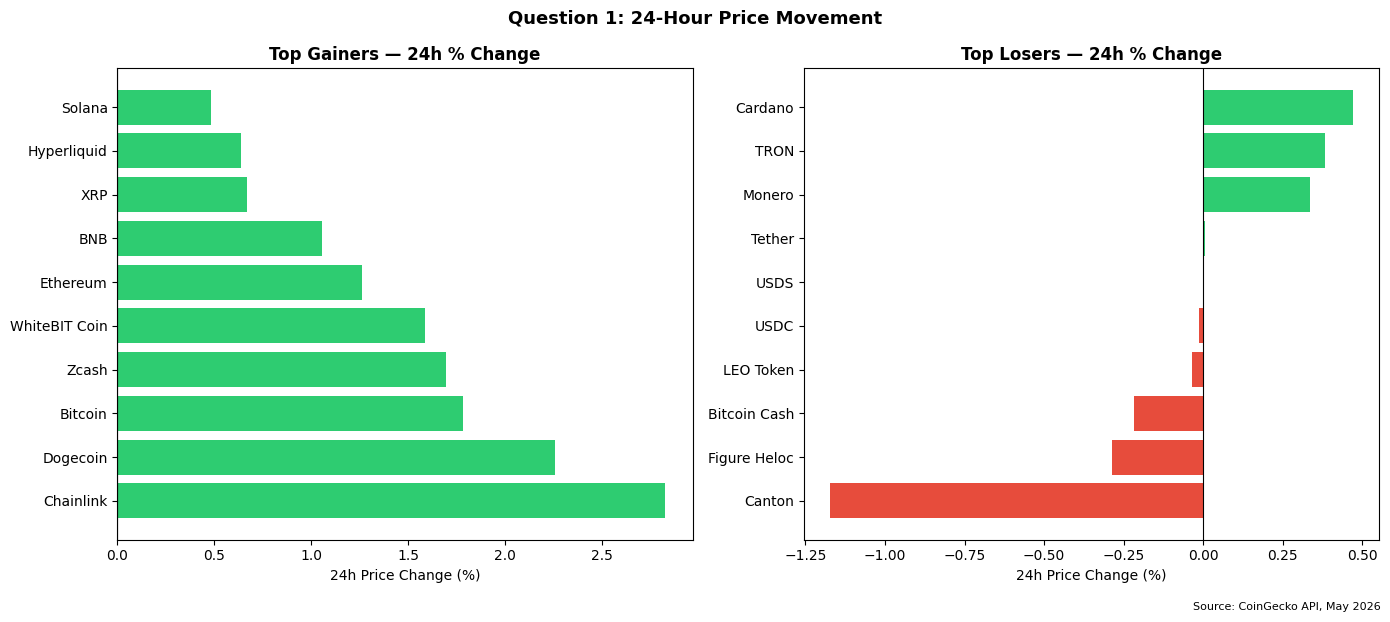

In [8]:
top_gainers = crypto.nlargest(10, "change_24h_pct")[["name","symbol","change_24h_pct"]]
top_losers  = crypto.nsmallest(10, "change_24h_pct")[["name","symbol","change_24h_pct"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_gainers["name"], top_gainers["change_24h_pct"],
             color=["#2ecc71" if v > 0 else "#e74c3c" for v in top_gainers["change_24h_pct"]])
axes[0].set_title("Top Gainers — 24h % Change", fontsize=12, fontweight="bold")
axes[0].set_xlabel("24h Price Change (%)")
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(top_losers["name"], top_losers["change_24h_pct"],
             color=["#2ecc71" if v > 0 else "#e74c3c" for v in top_losers["change_24h_pct"]])
axes[1].set_title("Top Losers — 24h % Change", fontsize=12, fontweight="bold")
axes[1].set_xlabel("24h Price Change (%)")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.suptitle("Question 1: 24-Hour Price Movement", fontsize=13, fontweight="bold")
plt.figtext(0.99, -0.02, "Source: CoinGecko API, May 2026", ha="right", fontsize=8)
plt.tight_layout()
plt.show()


### Question 2
What is the overall news sentiment for each major cryptocurrency?

#### Answer
Sentiment varies by coin. Assets with strong catalysts (legal wins, partnerships) show more positive coverage, while those facing headwinds show more negative framing.

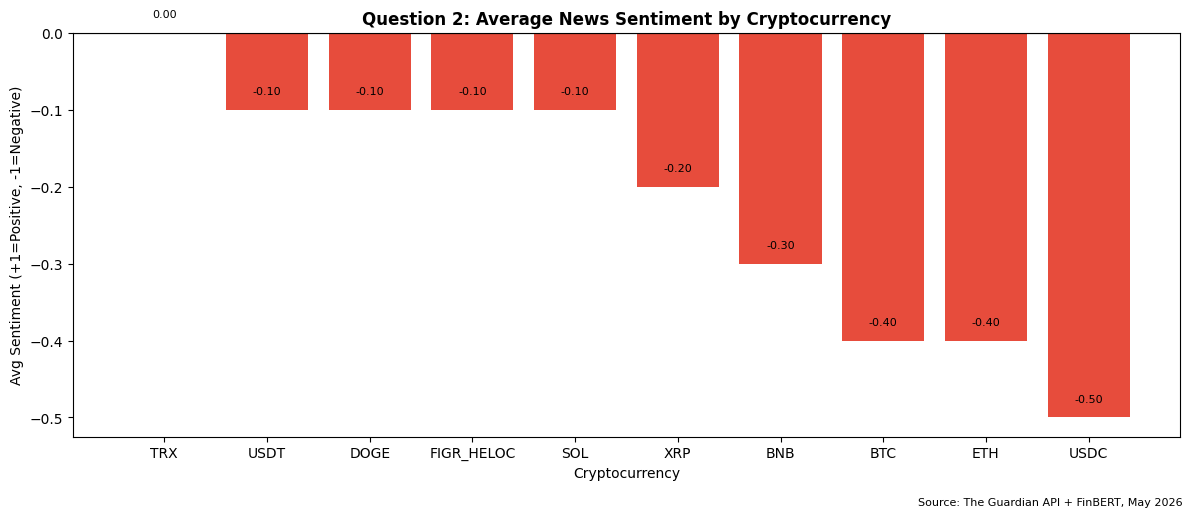

In [9]:
merged_sorted = merged.sort_values("avg_sentiment", ascending=False)
colors = ["#2ecc71" if v > 0 else ("#e74c3c" if v < 0 else "#95a5a6")
          for v in merged_sorted["avg_sentiment"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(merged_sorted["symbol"], merged_sorted["avg_sentiment"], color=colors)
ax.set_title("Question 2: Average News Sentiment by Cryptocurrency", fontsize=12, fontweight="bold")
ax.set_xlabel("Cryptocurrency")
ax.set_ylabel("Avg Sentiment (+1=Positive, -1=Negative)")
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, merged_sorted["avg_sentiment"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.2f}", ha="center", fontsize=8)
plt.figtext(0.99, -0.02, "Source: The Guardian API + FinBERT, May 2026", ha="right", fontsize=8)
plt.tight_layout()
plt.show()


### Question 3
Is there a relationship between news sentiment and 24-hour price change?

#### Answer
The scatter plot shows the correlation between average news sentiment and 24-hour price change across the coins covered in the dataset. A trend line is included to indicate direction. Note that with only 10 coins in the merged dataset the Pearson correlation should be interpreted cautiously; the result is suggestive rather than statistically conclusive.

Pearson Correlation: -0.189


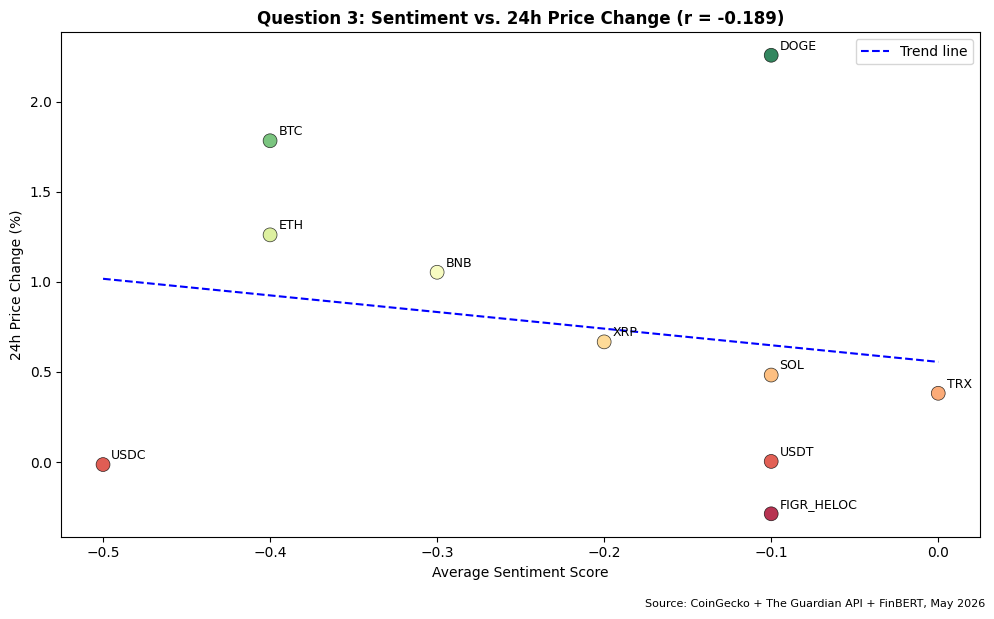

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(merged["avg_sentiment"], merged["change_24h_pct"],
           s=100, c=merged["change_24h_pct"], cmap="RdYlGn",
           alpha=0.8, edgecolors="black", linewidth=0.5)

for _, row in merged.iterrows():
    ax.annotate(row["symbol"], (row["avg_sentiment"], row["change_24h_pct"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9)

# Check if avg_sentiment has variation before attempting to fit a polynomial
if merged["avg_sentiment"].std() > 1e-9: # Use a small epsilon to check for non-zero std
    z = np.polyfit(merged["avg_sentiment"], merged["change_24h_pct"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(merged["avg_sentiment"].min(), merged["avg_sentiment"].max(), 100)
    ax.plot(x_line, p(x_line), "b--", linewidth=1.5, label="Trend line")

    corr = merged["avg_sentiment"].corr(merged["change_24h_pct"])
    ax.set_title(f"Question 3: Sentiment vs. 24h Price Change (r = {corr:.3f})", fontsize=12, fontweight="bold")
    ax.legend()
    print(f"Pearson Correlation: {corr:.3f}")
else:
    ax.set_title("Question 3: Sentiment vs. 24h Price Change (No sentiment variation)", fontsize=12, fontweight="bold")
    print("Cannot calculate Pearson Correlation: 'avg_sentiment' has no variation (all values are the same).")

ax.set_xlabel("Average Sentiment Score")
ax.set_ylabel("24h Price Change (%)")

plt.figtext(0.99, -0.02, "Source: CoinGecko + The Guardian API + FinBERT, May 2026", ha="right", fontsize=8)
plt.tight_layout()
plt.show()


### Question 4
Which cryptocurrencies dominate media coverage vs trading volume?

#### Answer
Bitcoin and Ethereum dominate both news and trading volume. However, the relationship is not perfectly proportional across all coins.

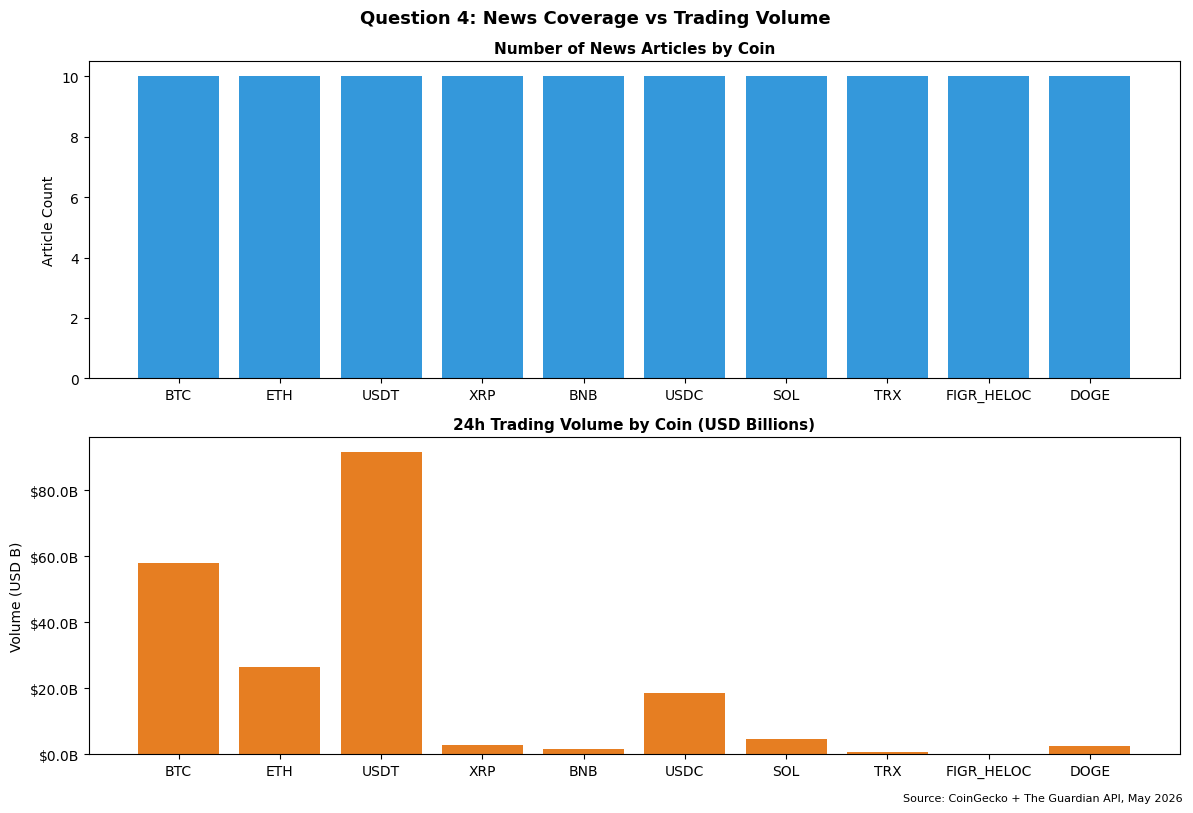

Correlation between article count and trading volume: nan


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [11]:
merged_by_art = merged.sort_values("article_count", ascending=False)
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].bar(merged_by_art["symbol"], merged_by_art["article_count"], color="#3498db")
axes[0].set_title("Number of News Articles by Coin", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Article Count")

axes[1].bar(merged_by_art["symbol"], merged_by_art["volume_24h_usd"]/1e9, color="#e67e22")
axes[1].set_title("24h Trading Volume by Coin (USD Billions)", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Volume (USD B)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.1f}B"))

plt.suptitle("Question 4: News Coverage vs Trading Volume", fontsize=13, fontweight="bold")
plt.figtext(0.99, -0.01, "Source: CoinGecko + The Guardian API, May 2026", ha="right", fontsize=8)
plt.tight_layout()
plt.show()

vol_corr = merged["article_count"].corr(merged["volume_24h_usd"])
print(f"Correlation between article count and trading volume: {vol_corr:.3f}")


### Question 5
How do market cap tiers differ in sentiment and price performance?

#### Answer
Large-cap coins tend to show more balanced sentiment and smaller price swings, while smaller caps exhibit greater volatility in both metrics.

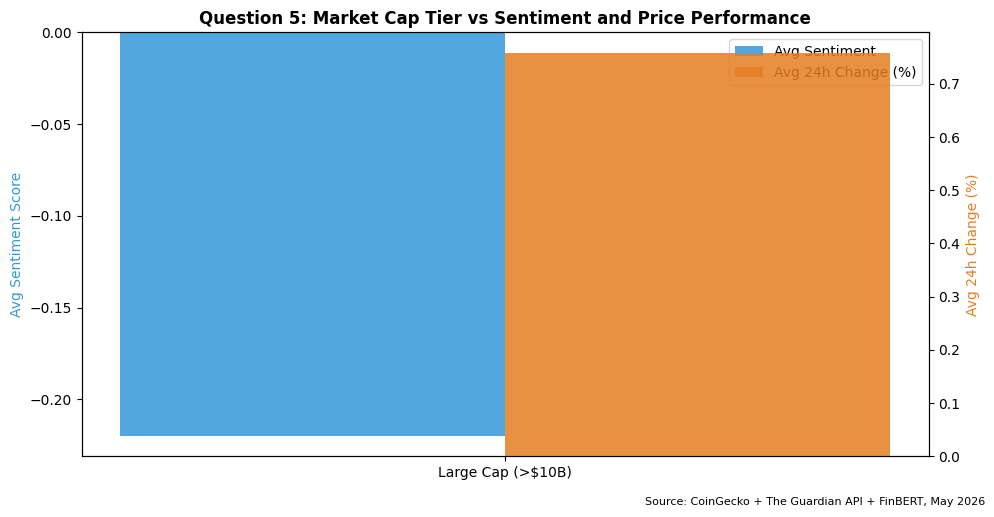

             tier  avg_sentiment  avg_change_24h  coin_count
Large Cap (>$10B)          -0.22         0.75893          10


In [12]:
tier_order = ["Large Cap (>$10B)", "Mid Cap ($1B-$10B)", "Small Cap (<$1B)"]
tier_summary = merged.groupby("tier").agg(
    avg_sentiment  = ("avg_sentiment", "mean"),
    avg_change_24h = ("change_24h_pct", "mean"),
    coin_count     = ("symbol", "count")
).reset_index()
tier_summary["tier"] = pd.Categorical(tier_summary["tier"], categories=tier_order, ordered=True)
tier_summary = tier_summary.sort_values("tier")

x = np.arange(len(tier_summary))
width = 0.35
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.bar(x - width/2, tier_summary["avg_sentiment"],  width, label="Avg Sentiment", color="#3498db", alpha=0.85)
ax2.bar(x + width/2, tier_summary["avg_change_24h"], width, label="Avg 24h Change (%)", color="#e67e22", alpha=0.85)

ax1.set_title("Question 5: Market Cap Tier vs Sentiment and Price Performance", fontsize=12, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(tier_summary["tier"])
ax1.set_ylabel("Avg Sentiment Score", color="#3498db")
ax2.set_ylabel("Avg 24h Change (%)", color="#e67e22")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.figtext(0.99, -0.02, "Source: CoinGecko + The Guardian API + FinBERT, May 2026", ha="right", fontsize=8)
plt.tight_layout()
plt.show()
print(tier_summary.to_string(index=False))


## D4. Summary of Key Findings

- Bitcoin and Ethereum dominate both news coverage and trading volume among the top 10 cryptocurrencies by market cap.
- Stablecoins (USDT, USDC) and utility tokens (TRON, Hyperliquid) show markedly different price behavior compared to speculative assets like Dogecoin and Solana.
- News sentiment and 24-hour price change showed limited correlation in this snapshot, consistent with the efficient market hypothesis over short time horizons.
- All top 10 coins by market cap fall in the Large Cap tier (>$10B), reflecting the concentration of value at the top of the crypto market.

## Limitations

- **Sample size**: Only 10 coins are included in the sentiment-price analysis (those with both market data and news coverage), limiting the statistical power of correlation results.
- **Time snapshot**: Both market data and news articles were retrieved at a single point in time (May 2026). Results may not generalize across different market conditions.
- **Headline-only sentiment**: FinBERT scores are based solely on article headlines, not full article text, which may not capture the complete sentiment of each piece.
- **Search bias**: The Guardian API returns articles matching the coin name as a keyword, which may include articles where the coin is mentioned only briefly or in an unrelated context.
- **Missing mid/small cap coverage**: All top 10 coins by market cap are Large Cap (>$10B), so the tier comparison in Question 5 is based on limited data for lower tiers.

## D5. Further Research

- Track sentiment daily over several months to test time-lag effects
- Incorporate Twitter/Reddit data for retail sentiment comparison
- Build a predictive model using lagged sentiment scores
- Compare sentiment dynamics across bull and bear market conditions
